# Phase resolved spectroscopy

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 2795
/bin/rm {acis,pcad}f*.fits 
download_chandra_obsid 2795
chandra_repro 2795 out="./" clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  1903.5 kb/s
  oif      fits       23 Kb  ####################          < 1 s  3526.1 kb/s
  vv       pdf        25 Kb  ####################          < 1 s  3708.9 kb/s
  cntr_img fits       31 Kb  ####################          < 1 s  4481.9 kb/s
  cntr_img jpg        80 Kb  ####################          < 1 s  7082.5 kb/s
  evt2     fits      656 Kb  ####################          < 1 s  28661.7 kb/s
  full_img fits       13 Kb  ####################          < 1 s  2149.2 kb/s
  full_img jpg         2 Kb  ####################          < 1 s  363.0 kb/s
  bpix     fits        4 Kb  ####################          < 1 s  765.2 kb/s
  fov      fits        5 Kb  ####################          < 1 s  796.7 kb/s
  eph1     fits      281 Kb  ####################          < 1 s 

## Look at data

In [3]:
cat << EOM > ciao.reg
circle(4132.0324,4032.858,9.7651047)
EOM

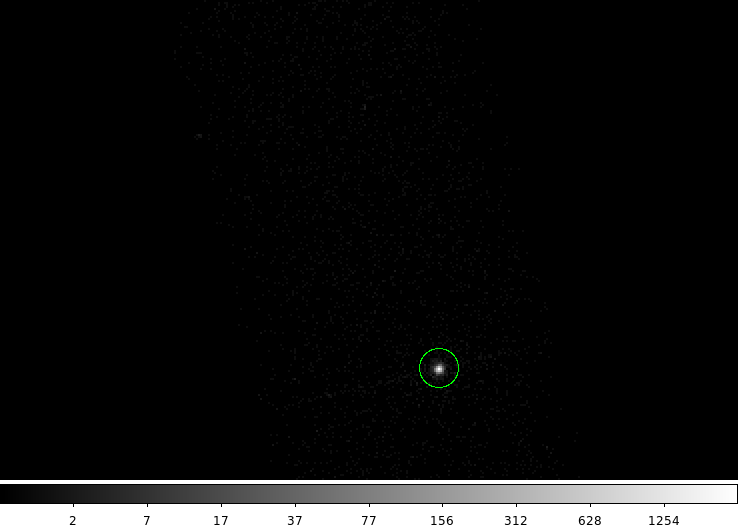

In [4]:
ds9 acisf02795_repro_evt2.fits -scale log -region ciao.reg -zoom 2 \
  -saveimage ds9_01.png -quit

display < ds9_01.png


In [5]:
dmcopy "acisf02795_repro_evt2.fits[sky=region(ciao.reg),energy=500:7000]" \
   RXJ0806.3+1527.evt clob+

## Bary Center Correction

In [6]:
punlearn dmcoords
dmcoords RXJ0806.3+1527.evt op=sky x=4132.0324 y=4032.858 celfmt=deg verb=0
ra=`pget dmcoords ra`
dec=`pget dmcoords dec`
echo $ra $dec

121.595693354536 15.45862476865555


In [7]:
axbary RXJ0806.3+1527.evt \
  2795/primary/orbitf121694700N001_eph1.fits.gz \
  RXJ0806.3+1527_bary.evt ra=${ra} dec=${dec} clobber=yes

Clobber the existing output file :  RXJ0806.3+1527_bary.evt

 
axbary_ar -i 2795/primary/orbitf121694700N001_eph1.fits.gz -f RXJ0806.3+1527.evt -o RXJ0806.3+1527_bary.evt -ra 121.595693354536 -dec 15.45862476865555 -debug
 
axBary: Principal HDU  -  TIERRELA = 0.000000, TIERABSO = 0.000050
axBary: Clock correction 0.000000 -  TIERABSO = -1.000000
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 0
axBary: HDU 0 TSTART = 121940918.990110, TSTOP = 121964279.253540
axBary: HDU 0 TSTART = 121941081.557234, TSTOP = 121964444.020373 (corrected)
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 1
axBary: HDU 1 TSTART = 121940918.990110, TSTOP = 121964279.253540
axBary: HDU 1 TSTART = 121941081.557234, TSTOP = 121964444.020373 (corrected)
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 2
axBary: HDU 2 TSTART = 121940918.990110, TSTOP = 121964279.253540
axBary: HDU 2 TSTART = 121941081.557234, T

In [8]:
axbary pcadf121941470N004_asol1.fits \
    2795/primary/orbitf121694700N001_eph1.fits.gz \
    RXJ0806.3+1527_bary.asol ra=${ra} de=${dec} clobber=yes

Clobber the existing output file :  RXJ0806.3+1527_bary.asol

 
axbary_ar -i 2795/primary/orbitf121694700N001_eph1.fits.gz -f pcadf121941470N004_asol1.fits -o RXJ0806.3+1527_bary.asol -ra 121.595693354536 -dec 15.45862476865555 -debug
 
axBary: Principal HDU  -  TIERRELA = 0.000000, TIERABSO = 0.000050
axBary: Clock correction 0.000000 -  TIERABSO = -1.000000
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 0
axBary: HDU 0 TSTART = 121941471.208880, TSTOP = 121962693.065980
axBary: HDU 0 TSTART = 121941633.827609, TSTOP = 121962857.682217 (corrected)
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 1
axBary: HDU 1 TSTART = 121941471.208880, TSTOP = 121962693.065980
axBary: HDU 1 TSTART = 121941633.827609, TSTOP = 121962857.682217 (corrected)


In [9]:
dmhedit RXJ0806.3+1527_bary.evt file= op=add key=asolfile value=RXJ0806.3+1527_bary.asol

In [10]:
axbary acisf02795_000N003_stat1.fits \
  2795/primary/orbitf121694700N001_eph1.fits.gz \
  RXJ0806.3+1527_bary.expstats ra=${ra} de=${dec} clobber=yes

Clobber the existing output file :  RXJ0806.3+1527_bary.expstats

 
axbary_ar -i 2795/primary/orbitf121694700N001_eph1.fits.gz -f acisf02795_000N003_stat1.fits -o RXJ0806.3+1527_bary.expstats -ra 121.595693354536 -dec 15.45862476865555 -debug
 
axBary: Principal HDU  -  TIERRELA = 0.000000, TIERABSO = 0.000050
axBary: Clock correction 0.000000 -  TIERABSO = -1.000000
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 0
axBary: HDU 0 TSTART = 121940918.990110, TSTOP = 121964279.253540
axBary: HDU 0 TSTART = 121941081.557234, TSTOP = 121964444.020373 (corrected)
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 1
axBary: HDU 1 TSTART = 121940918.990110, TSTOP = 121964279.253540
axBary: HDU 1 TSTART = 121941081.557234, TSTOP = 121964444.020373 (corrected)
axBary: Using JPL Planetary Ephemeris DE-405
axBary: bary stuff initialized in HDU 2
axBary: HDU 2 TSTART = 121940918.990110, TSTOP = 121964279.253540
axBary: HDU 2 TSTART 

## Create lightcurve

In [11]:
 dmextract "RXJ0806.3+1527_bary.evt[bin time=::20]" RXJ0806.3+1527.lc op=ltc1 clob+ 

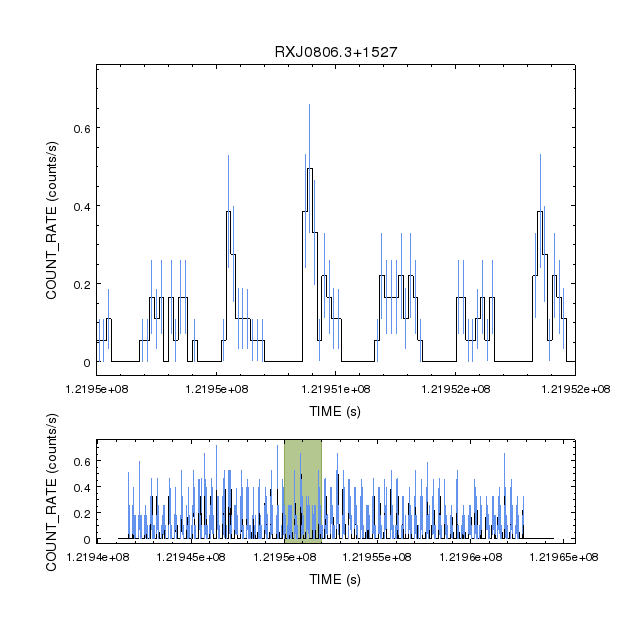

In [12]:
cat << EOM > c1.py
tab = read_file("RXJ0806.3+1527.lc")

xl = tab.get_column("time_min").values
xh = tab.get_column("time_max").values
y = tab.get_column("count_rate").values
ye = tab.get_column("count_rate_err").values

add_histogram( xl, xh , y, ye, "err.color=cornflower" )

limits(X_AXIS, 121950000, 121952000)
set_plot_ylabel("COUNT\_RATE (counts/s)")
set_plot_xlabel("TIME (s)")
set_plot_title("RXJ0806.3+1527")

split(2, 1, 0.1)
adjust_grid_yrelsize( 1, 3)

add_histogram( xl, xh , y, ye, "err.color=cornflower" )
set_plot_ylabel("COUNT\_RATE (counts/s)")
set_plot_xlabel("TIME (s)")
add_region( [121950000, 121950000, 121952000, 121952000], [-1,1,1,-1], "*.color=olive depth=99")
print_window("chips_01.png","export.clobber=True")
quit()
EOM

chips -n c1.py
display < chips_01.png


## GLVARY

In [13]:
 glvary RXJ0806.3+1527_bary.evt outfile=glvary.prob lcfile=glvary.lc effile="" clob+

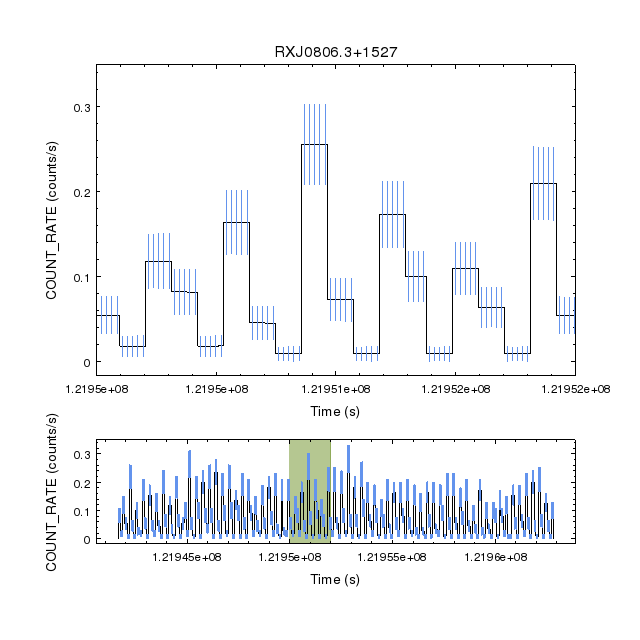

In [14]:
cat << EOM > c2.py
tab = read_file("glvary.lc")
xx = tab.get_column("Time").values
yy = tab.get_column("count_rate").values
ye = tab.get_column("count_rate_err").values

add_histogram( xx, None , yy, ye, "err.color=cornflower" )
set_plot_title("RXJ0806.3+1527")
set_plot_ylabel("COUNT\_RATE (counts/s)")
set_plot_xlabel("Time (s)")
limits(X_AXIS, 121950000, 121952000)

split(2, 1, 0.1)
adjust_grid_yrelsize( 1, 3)

add_histogram( xx, None , yy, ye, "err.color=cornflower" )
set_plot_ylabel("COUNT\_RATE (counts/s)")
set_plot_xlabel("Time (s)")

add_region( [121950000, 121950000, 121952000, 121952000], [-1,1,1,-1], "*.color=olive depth=99")

print_window("chips_02.png","export.clobber=True")
quit()
EOM

chips -n c2.py
display < chips_02.png 

## Power spectrum

In [15]:
dmstat "RXJ0806.3+1527.lc[cols count_rate]" verb=0 
mean=`pget dmstat out_mean`
echo $mean

0.072743979034


In [16]:
 dmtcalc RXJ0806.3+1527.lc RXJ0806.3+1527_mean_offset.lc \
   exp="count_rate=count_rate-${mean}" clob+

In [17]:
apowerspectrum infilereal="RXJ0806.3+1527_mean_offset.lc[cols time,count_rate]" infileimag=none \
  outfile=RXJ0806.3+1527.power clob+

dmlist RXJ0806.3+1527.power cols

 
--------------------------------------------------------------------------------
Columns for Table Block POWERSPECTRUM
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   FREQUENCY            (s)**-1      Real8          -Inf:+Inf            
   2   DATA                              Real4          -Inf:+Inf            


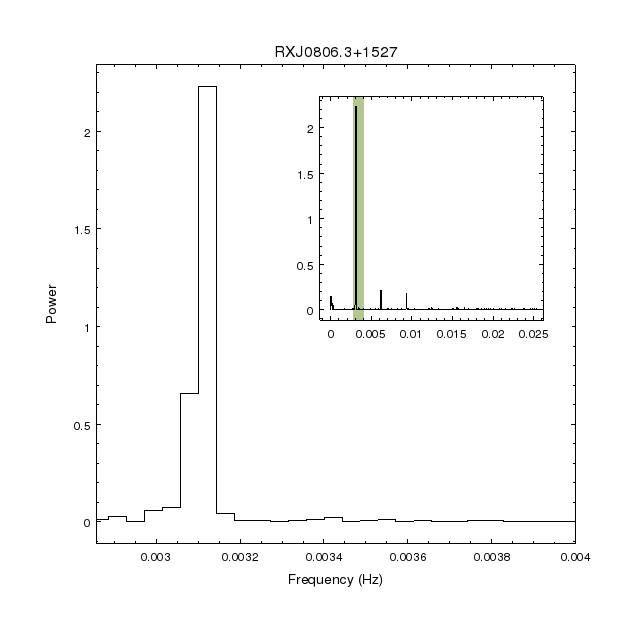

In [18]:
cat << EOM > c3.py
add_histogram("RXJ0806.3+1527.power")
limits(X_AXIS, 1.0/350, 1.0/250)

set_plot_xlabel("Frequency (Hz)")
set_plot_ylabel("Power")
set_plot_title("RXJ0806.3+1527")

#Create the inset plot
add_plot(0.5, 0.5, 0.85,0.85)
add_histogram("RXJ0806.3+1527.power")
add_region(  [1.0/350,  1.0/350,  1.0/250,  1.0/250],[-1,10,10,-1], "*.color=olive depth=99")

limits(X_AXIS, AUTO, 0.026239)
print_window("chips_03.png","export.clobber=True")
quit()

EOM

chips -n c3.py
display < chips_03.png


## Period Fold

In [19]:
dmkeypar RXJ0806.3+1527_bary.evt tstart echo+

121941081.557234


In [20]:
pfold RXJ0806.3+1527_bary.evt RXJ0806.3+1527.fold periodgrid=300:400:0.01 \
   tzero=121941081.557 clobber=yes

In [21]:
dmlist RXJ0806.3+1527.fold cols,blocks

 
--------------------------------------------------------------------------------
Dataset: RXJ0806.3+1527.fold
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: RXJ0806.3+1527.fold            Table         8 cols x 10001    rows
 
--------------------------------------------------------------------------------
Columns for Table Block RXJ0806.3+1527.fold
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   PERIOD               sec          Real8          -Inf:+Inf            Folded Period
   2   PHASE_MID[10]                     Real8(10)      -Inf:+Inf            PHASE GRID
   3   COUNTS[10]                        Int4(10)       -              

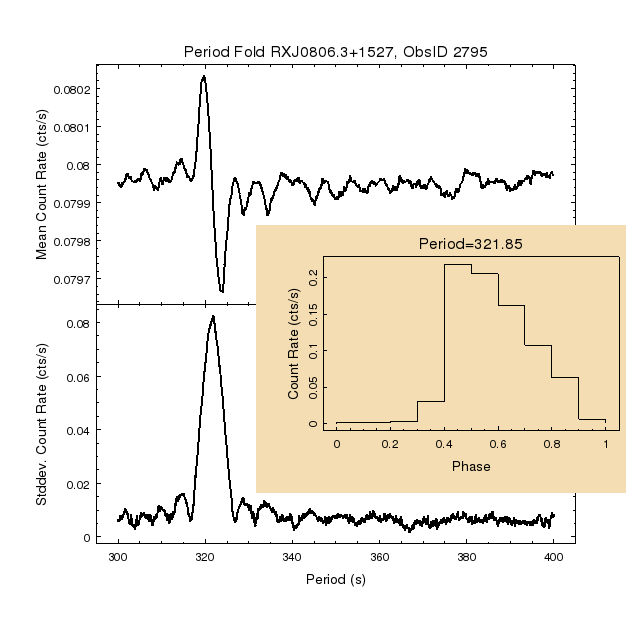

In [22]:
cat << EOM > c4.py

strip_chart(2)
add_curve( "RXJ0806.3+1527.fold[cols period,mean_rate]", "symbol.style=none line.thickness=2")
set_plot_ylabel("Mean Count Rate (cts/s)")
set_plot_title("Period Fold RXJ0806.3+1527, ObsID 2795")
set_axis("ay1", "offset.perpendicular=50")

set_current_plot("plot2")
add_curve( "RXJ0806.3+1527.fold[cols period,sigma_rate]","symbol.style=none line.thickness=2")
set_plot_ylabel("Stddev. Count Rate (cts/s)")
set_plot_xlabel("Period (s)")
set_axis("ay1", "offset.perpendicular=50")

add_frame( 0.4,0.23, 0.98,0.65, "bgcolor=wheat")
tab = read_file("RXJ0806.3+1527.fold[period=321.85]")
add_histogram(tab.get_column("phase_mid").values, tab.get_column("rate").values)
set_plot_title("Period=321.85")
set_plot_xlabel("Phase")
set_plot_ylabel("Count Rate (cts/s)")
set_axis("ay1", "ticklabel.angle=90 ticklabel.halign=0.5 ticklabel.valign=0 offset.perpendicular=25")
hide_minor_ticks("ay1")
set_plot("bottommargin=0.23 topmargin=0.12 leftmargin=0.18 rightmargin=0.02 style=boxed")

print_window("chips_04.png","export.clobber=True")

quit()
EOM

chips -n c4.py
display < chips_04.png

### dmtype2split

In [23]:
dmtype2split RXJ0806.3+1527.fold"[period=321.85]" 321.85.fits cl+
dmlist 321.85.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block 321.85.fits
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   PHASE_MID                         Real8          -Inf:+Inf            
   2   COUNTS                            Int4           -                    
   3   RATE                 counts/sec   Real8          -Inf:+Inf            
   4   ONTIME               sec          Real8          -Inf:+Inf            
   5   DTF                               Real8          -Inf:+Inf            


## Compute Phase


In [24]:
cat << EOM > dmtcalc.expr
.period=321.85
.tzero=121941081.5572
.freq=(1.0/.period)
GPHASE=((time-(.tzero))*.freq)
PHASE=(GPHASE-((long)GPHASE))
EOM

In [25]:
dmtcalc RXJ0806.3+1527_bary.evt RXJ0806.3+1527_phase.evt exp=@dmtcalc.expr clob+ 
dmlist RXJ0806.3+1527_phase.evt cols

 
--------------------------------------------------------------------------------
Columns for Table Block EVENTS
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   time                 s            Real8          121941081.5572299957:121964444.0203700066 Time elapsed since MJDREF
   2   expno                             Int4           0:2147483647         Exposure number of CCD frame containing event
   3   ccd_id                            Int2           0:9                  CCD reporting event
   4   node_id                           Int2           0:3                  CCD serial readout amplifier node
   5   chip(chipx,chipy)    pixel        Int2           1:1024               Chip coords
   6   tdet(tdetx,tdety)    pixel        Int2           1:8192               ACIS tiled detector coordinates
   7   det(detx,dety)       pixel        Real4          0.50:     8192.50    ACIS detec

In [26]:
dmextract "RXJ0806.3+1527_phase.evt[bin phase=0.0:1.0:0.1]" phase.lc op=generic clob+

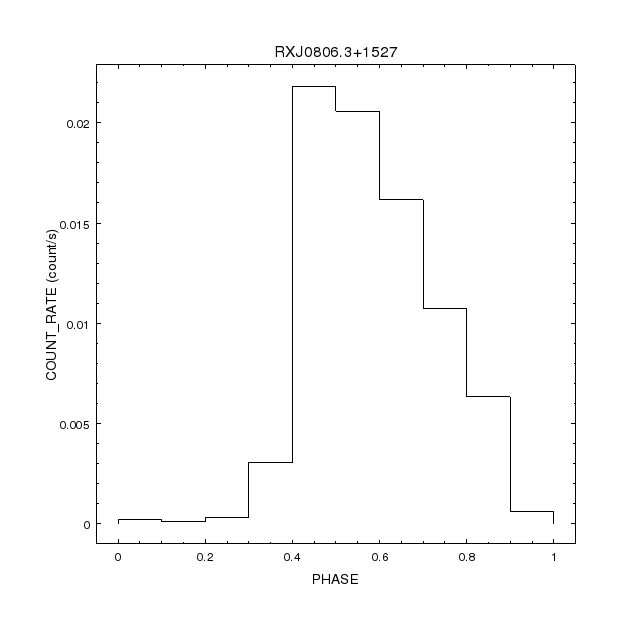

In [27]:
cat << EOM > c5.py 
make_figure("phase.lc[cols phase,count_rate]", "histogram")
print_window("chips_05.png","export.clobber=True")
quit()
EOM

chips -n c5.py
display < chips_05.png

## Create GTIs

In [28]:
dmtcalc RXJ0806.3+1527_bary.asol RXJ0806.3+1527_phase.asol exp=@dmtcalc.expr clob+

In [29]:
pset dmgti infile=RXJ0806.3+1527_phase.asol
pset dmgti outfile=high.gti
pset dmgti userlimit="((0.4<=phase)&&(phase<0.9))"
dmgti mode=h clobber=yes

In [30]:
dmlist high.gti blocks

 
--------------------------------------------------------------------------------
Dataset: high.gti
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: FILTER                         Table         1 cols x 0        rows
Block    3: GTI                            Table         2 cols x 67       rows


## Align GTIs

In [31]:
pset gti_align times=high.gti
pset gti_align statfile=RXJ0806.3+1527_bary.expstats
pset gti_align outfile=high_align.gti
pset gti_align evtfile=RXJ0806.3+1527_bary.evt
gti_align mode=h clobber=yes

gti_align
           times = high.gti
        statfile = RXJ0806.3+1527_bary.expstats
         outfile = high_align.gti
         evtfile = RXJ0806.3+1527_bary.evt
         clobber = yes
         verbose = 1
            mode = h



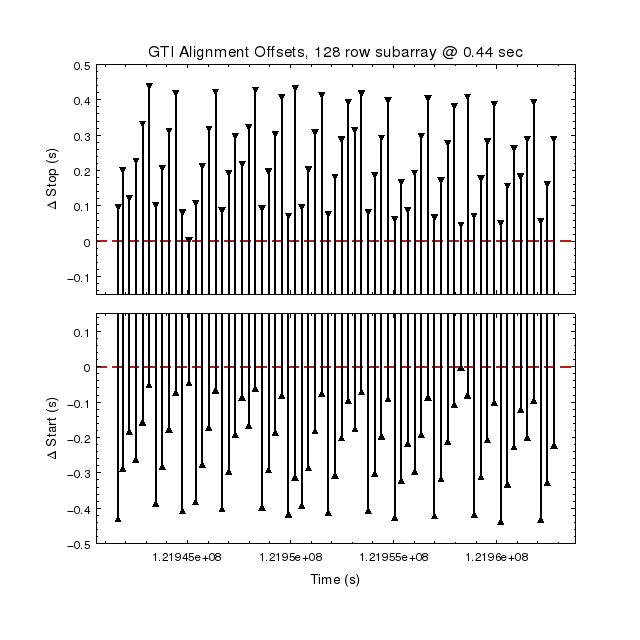

In [32]:
cat << EOM > c6.py
orig = read_file("high.gti[3]")
orig_lo = orig.get_column("start").values
orig_hi = orig.get_column("stop").values
fix = read_file("high_align.gti[3]")
lo = fix.get_column("start").values
hi = fix.get_column("stop").values

for l,h,ol,oh in zip( lo, hi, orig_lo, orig_hi ):
    add_curve( [ol, ol], [l-oh, h-oh], 'symbol.style=downtriangle symbol.size=5 line.thickness=2')

set_plot_ylabel("\Delta Stop (s)")
set_plot_title("GTI Alignment Offsets, 128 row subarray @ 0.44 sec")
limits(Y_AXIS, -0.15, 0.5)
add_hline(0, "thickness=2 color=firebrick style=longdash depth=50")
hide_axis("ax1")

split(2,1)
adjust_grid_ygap(0.03)

for l,h,ol,oh in zip( lo, hi, orig_lo, orig_hi ):
    add_curve( [ol, ol], [l-ol, h-ol], 'symbol.style=uptriangle symbol.size=5 line.thickness=2')

set_plot_ylabel("\Delta Start (s)")
set_plot_xlabel("Time (s)")
limits(Y_AXIS, -0.5, 0.15)
add_hline(0, "thickness=2 color=firebrick style=longdash depth=50")
print_window("chips_06.png","export.clobber=True")
quit()
EOM

chips -n c6.py
display < chips_06.png

In [33]:
dmkeypar "RXJ0806.3+1527_bary.evt[@high.gti]" ontime echo+

10601.974008739


In [34]:
dmkeypar "RXJ0806.3+1527_bary.evt[@high_align.gti]" ontime echo+

10633.0197870433


## Display good time

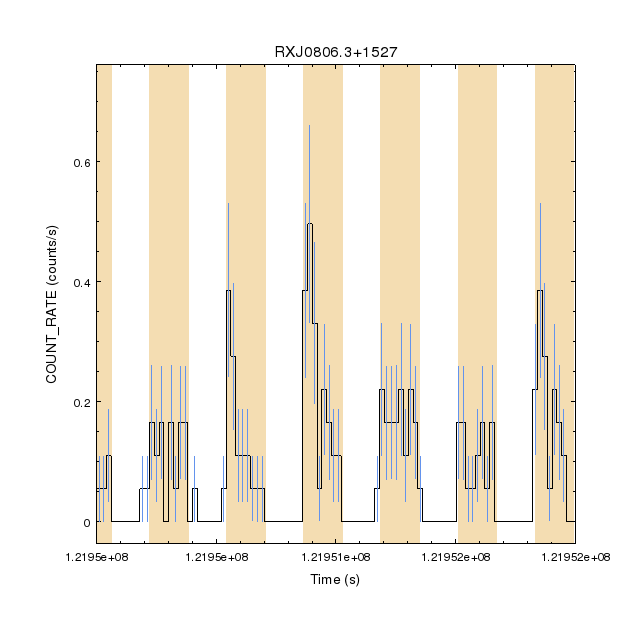

In [35]:
cat << EOM > c7.py
tab = read_file("RXJ0806.3+1527.lc")
xl = tab.get_column("time_min").values
xh = tab.get_column("time_max").values
y = tab.get_column("count_rate").values
ye = tab.get_column("count_rate_err").values
add_histogram( xl, xh , y, ye, "err.color=cornflower" )

gti = read_file("high_align.gti[gti7]")
lo = gti.get_column("start").values
hi = gti.get_column("stop").values
for l,h in zip(lo,hi):
    add_region( [l,l,h,h], [-1,1,1,-1], "*.color=wheat depth=99 opacity=1")

limits(X_AXIS, 121950000, 121952000)
set_plot_ylabel("COUNT\_RATE (counts/s)")
set_plot_xlabel("Time (s)")
set_plot_title("RXJ0806.3+1527")

print_window("chips_07.png","export.clobber=True")
quit()
EOM

chips -n c7.py
display < chips_07.png


## Extract Spectrum


In [36]:
dmcopy RXJ0806.3+1527_bary.evt"[@high_align.gti]" RXJ0806.3+1527_high.evt clob+

In [37]:
specextract "RXJ0806.3+1527_high.evt[sky=region(ciao.reg)]" RXJ0806.3+1527_high clob+


Running specextract
Version: 30 November 2016

Using event file RXJ0806.3+1527_high.evt[sky=region(ciao.reg)]

Aspect solution file RXJ0806.3+1527_bary.asol found.

Bad-pixel file acisf02795_repro_bpix1.fits found.

Mask file acisf02795_000N003_msk1.fits found.

Setting bad pixel file 

Extracting src spectra 

Creating src ARF 

Creating src RMF 

Using mkacisrmf...

Grouping src spectrum 

Updating header of RXJ0806.3+1527_high.pi with RESPFILE and ANCRFILE keywords.

Updating header of RXJ0806.3+1527_high_grp.pi with RESPFILE and ANCRFILE keywords.



read ARF file RXJ0806.3+1527_high.arf
read RMF file RXJ0806.3+1527_high.rmf


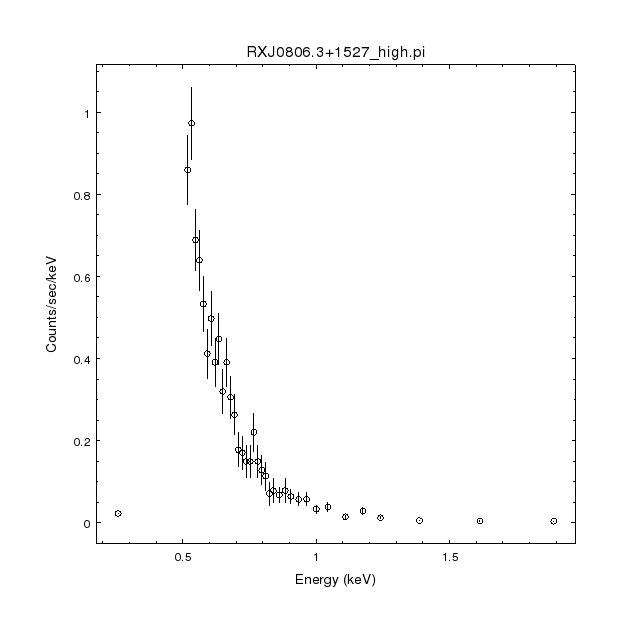

In [38]:
cat << EOM > s1.py
load_data("RXJ0806.3+1527_high.pi")
group_counts(10)
notice(0.3, 2.0 )
plot_data()

print_window("sherpa_01.png","export.clobber=True")
quit()
EOM

sherpa -n s1.py
display < sherpa_01.png


# Cleanup


In [ ]:
/bin/rm -f acisf* pcadf* 
/bin/rm -rf 2795